In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Nadam

In [28]:
data = pd.read_csv('Impute_misvalues_hungyen.csv')
data.head()

,Date,Hour,Waterlevel
0,01/01/2008,0,47.0
1,01/01/2008,1,43.0
2,01/01/2008,2,40.0
3,01/01/2008,3,37.0
4,01/01/2008,4,34.0


In [29]:
data['Hour'] = data['Hour'].replace('#NUM!', 0)
data['Hour'] = pd.to_datetime(data['Hour'], format='%H', errors='coerce').dt.time

scaler = StandardScaler()
scaled_levels = scaler.fit_transform(data[['Waterlevel']])
data['Waterlevel'] = scaled_levels

data['Hour'] = data['Hour'].astype(str)


data['DateTime'] = pd.to_datetime(data['Date'] + ' ' + data['Hour'])
data = data.set_index('DateTime')
data.drop(['Date', 'Hour'], axis = 1, inplace = True)

data.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,-0.939346
2008-01-01 01:00:00,-0.980575
2008-01-01 02:00:00,-1.011496
2008-01-01 03:00:00,-1.042418
2008-01-01 04:00:00,-1.073340


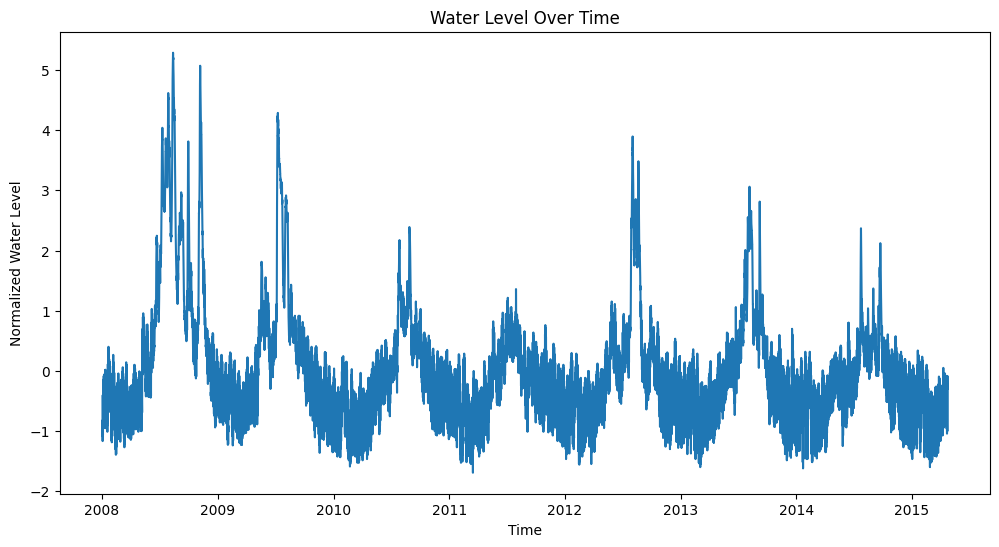

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Waterlevel'])
plt.title('Water Level Over Time')
plt.xlabel('Time')
plt.ylabel('Normalized Water Level')
plt.show()

In [31]:
def create_timesteps(data, timesteps):
    x, y = [], []
    for i in range(len(data) - timesteps):
        x.append(data[i:(i + timesteps), np.newaxis])  
        y.append(data[i + timesteps])
    return np.array(x), np.array(y)

timesteps = 18
x, y = create_timesteps(data['Waterlevel'].values[:, np.newaxis], timesteps) 


x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# def create_sequences(data, sequence_length):
#     xs, ys = [], []
#     for i in range(len(data) - sequence_length):
#         xs.append(data[i:(i + sequence_length)])
#         ys.append(data[i + sequence_length])
#     return np.array(xs), np.array(ys)

# sequence_length = 18
# X, y = create_sequences(data['Waterlevel'].values, sequence_length)

# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)

# x_train, x_test, y_train, y_test

In [32]:
x_train, x_val, y_train, y_val

(array([[[[-0.25907218]],
 
         [[-0.28999372]],
 
         [[-0.33122245]],
 
         ...,
 
         [[-0.77443126]],
 
         [[-0.80535281]],
 
         [[-0.81565999]]],
 
 
        [[[-0.37245118]],
 
         [[-0.39306554]],
 
         [[-0.4136799 ]],
 
         ...,
 
         [[-0.70228099]],
 
         [[-0.6404379 ]],
 
         [[-0.61982354]]],
 
 
        [[[-1.12487544]],
 
         [[-0.98057489]],
 
         [[-0.85688871]],
 
         ...,
 
         [[-0.88781026]],
 
         [[-0.94965335]],
 
         [[-1.01149644]]],
 
 
        ...,
 
 
        [[[-0.25907218]],
 
         [[-0.28999372]],
 
         [[-0.32091527]],
 
         ...,
 
         [[ 0.05014327]],
 
         [[-0.00139264]],
 
         [[-0.05292855]]],
 
 
        [[[-0.5270589 ]],
 
         [[-0.31060809]],
 
         [[-0.10446445]],
 
         ...,
 
         [[-0.26937936]],
 
         [[-0.31060809]],
 
         [[-0.362144  ]]],
 
 
        [[[-0.70228099]],
 
         [[-0.650745

In [33]:
from tensorflow.keras.layers import Layer
import tensorflow as tf

class Attention(Layer):
    def __init__(self, return_sequences=True):
        self.return_sequences = return_sequences
        super(Attention, self).__init__()
        
    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1),
                               initializer="zeros")
        
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        
        if self.return_sequences:
            return output
        
        return tf.reduce_sum(output, axis=1)


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model_CNN_AM = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(timesteps, 1)),
    MaxPooling1D(pool_size=2),
    Attention(return_sequences=True), 
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

model_CNN_AM.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mean_squared_error'])


C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0680 - mean_squared_error: 0.0680 - val_loss: 0.0017 - val_mean_squared_error: 0.0017
Epoch 2/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0016 - mean_squared_error: 0.0016 - val_loss: 9.3065e-04 - val_mean_squared_error: 9.3065e-04
Epoch 3/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 0.0011 - val_mean_squared_error: 0.0011
Epoch 4/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.3683e-04 - mean_squared_error: 9.3683e-04 - val_loss: 8.8925e-04 - val_mean_squared_error: 8.8925e-04
Epoch 5/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.0092e-04 - mean_squared_error: 9.0092e-04 - val_loss: 7.7119e-04 - val_mean_squared_error: 7.7119e-04
Epoch 6/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 7.8981e-04 - mean_squared_error: 7.8981e-04 - val_loss: 8.8839e-04 - val_mean_squared_error: 8.8839e-04
Epoch 7/50
1602/1602 ━━━━━━━━━━━━━━━━━━━━ 4s

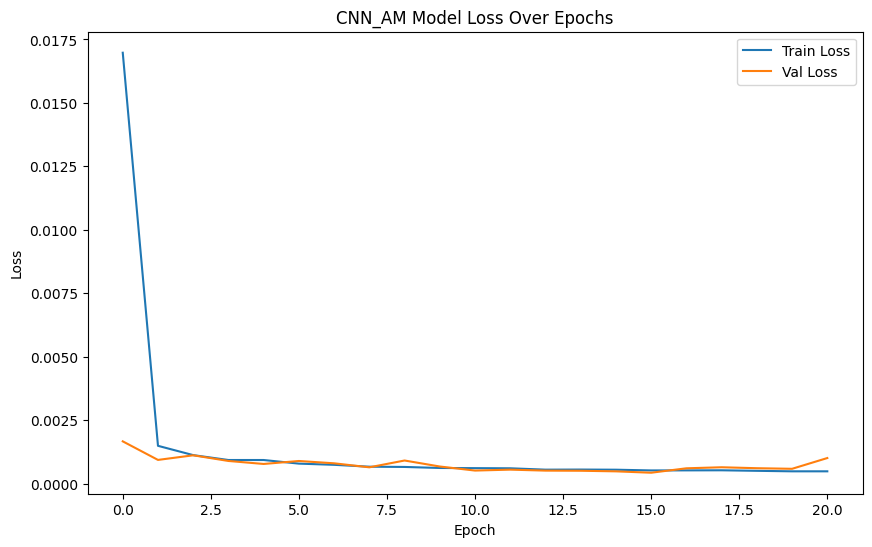

In [35]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_CNN_AM = model_CNN_AM.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), batch_size=32, verbose=1, callbacks=[early_stop])

test_loss_CNN_AM, test_mse_CNN_AM = model_CNN_AM.evaluate(x_test, y_test)
print("Test MSE for CNN_AM:", test_mse_CNN_AM)  

plt.figure(figsize=(10, 6))
plt.plot(history_CNN_AM.history['loss'], label='Train Loss')
plt.plot(history_CNN_AM.history['val_loss'], label='Val Loss')
plt.title('CNN_AM Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [36]:
from sklearn.metrics import mean_squared_error

def forecast(model, initial_data, steps, sequence_length=1, num_features=1):
    prediction = []
    input_data = np.array(initial_data.copy())
    if input_data.ndim == 1:
        input_data = input_data.reshape(sequence_length, num_features)
        print("inputdata:", input_data)
    
    for i in range(steps):
        next_step = model.predict(input_data[np.newaxis, :])
        prediction.append(next_step.flatten())
        input_data = np.roll(input_data, -num_features, axis=0)
        input_data[-1, :] = next_step
        
    return np.array(prediction)


time_steps_forecast = [12, 24, 36, 72]
results = []
for steps in time_steps_forecast:
    predictions = forecast(model_CNN_AM, x_test[0], steps)
    true_values = y_test[:steps]
    mse = mean_squared_error(true_values, predictions)
    results.append((steps, mse))
    print(f"Forecast for {steps} hours: MSE = {mse}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Forecast for 12 hours: MSE = 1.8086092191242935
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Forecast for 12 hours: MSE = 1.8086092191242935


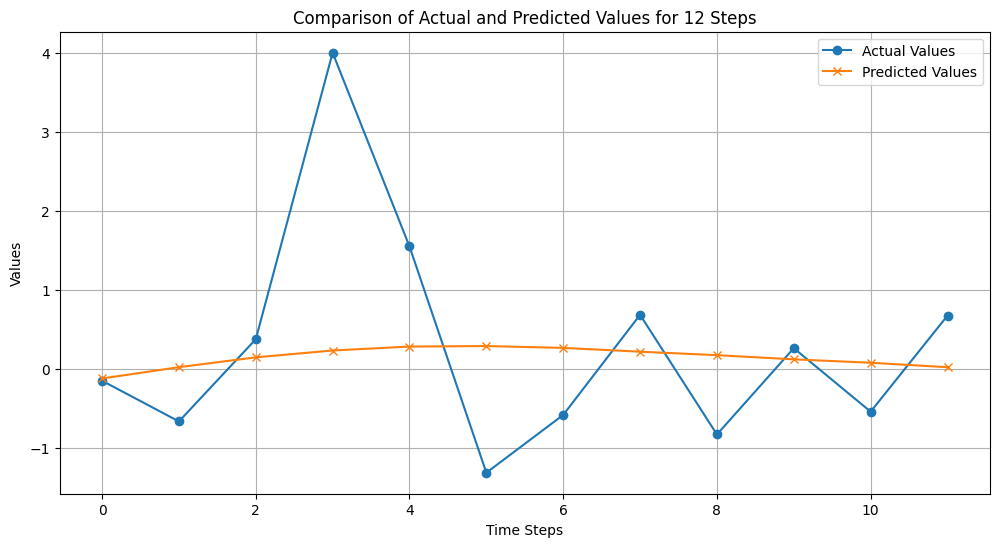

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Forecast for 24 hours: MSE = 2.912458741757842


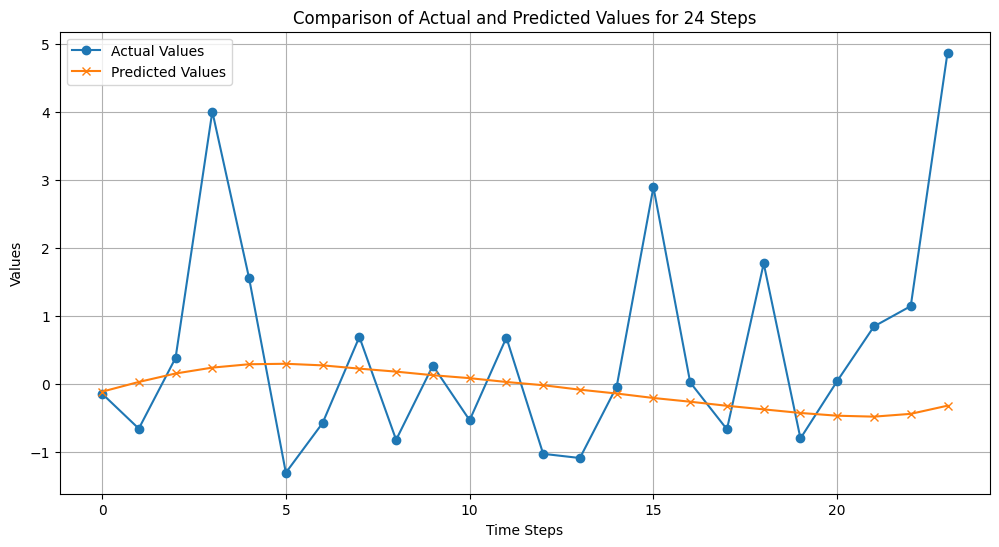

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

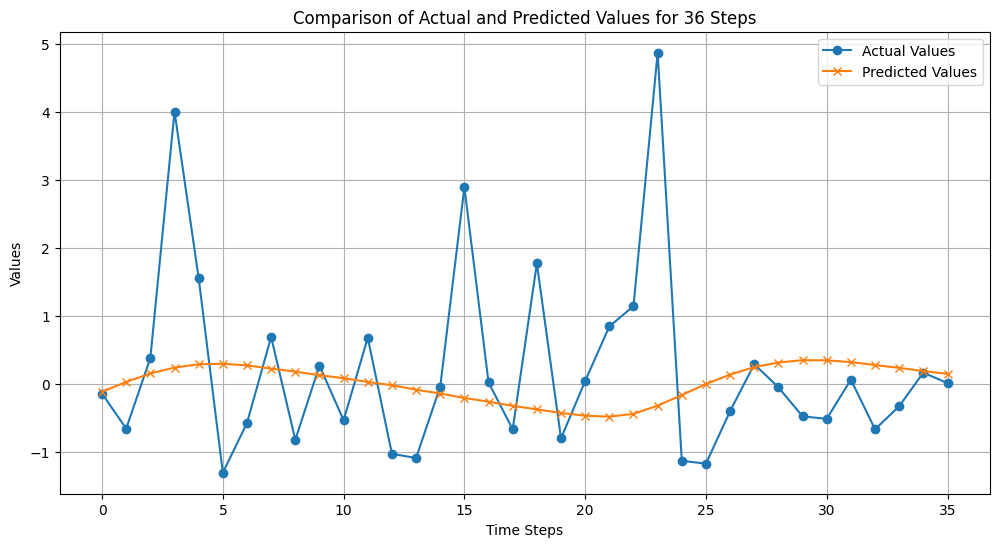

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

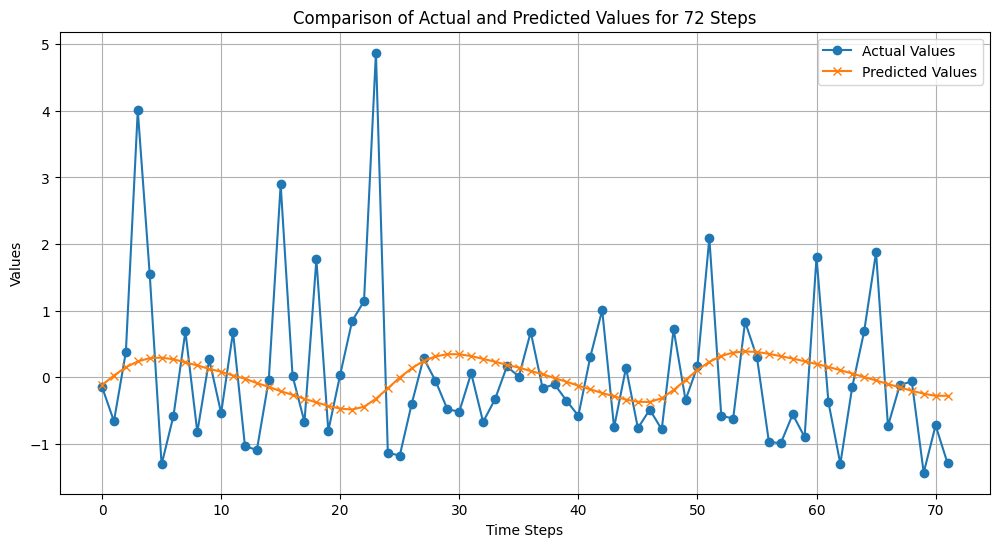

In [37]:
def plot_predictions(time_steps_forecast, model, x_test, y_test):
    for steps in time_steps_forecast:
        predictions = forecast(model, x_test[0], steps)
        true_values = y_test[:steps]
        mse = mean_squared_error(true_values, predictions)
        results.append((steps, mse))
        print(f"Forecast for {steps} hours: MSE = {mse}")


        
        
        plt.figure(figsize=(12, 6))
        plt.plot(range(steps), true_values, label='Actual Values', marker='o')
        plt.plot(range(steps), predictions, label='Predicted Values', marker='x')
        plt.title(f'Comparison of Actual and Predicted Values for {steps} Steps')
        plt.xlabel('Time Steps')
        plt.ylabel('Values')
        plt.legend()
        plt.grid(True)
        plt.show()
plot_predictions(time_steps_forecast, model_CNN_AM, x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Forecast for 12 hours: MSE = 0.781207466853029


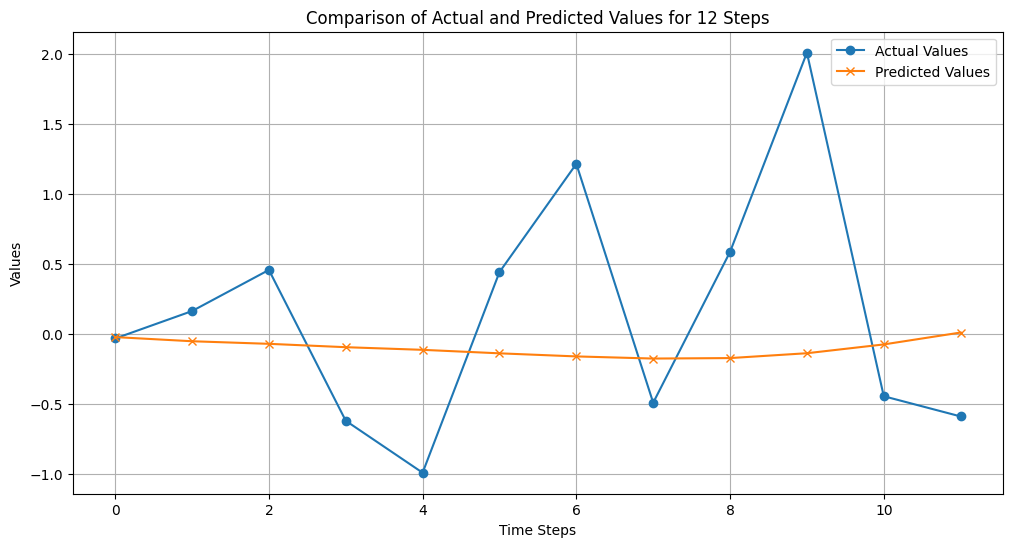

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Forecast for 24 hours: MSE = 0.8124438840809342


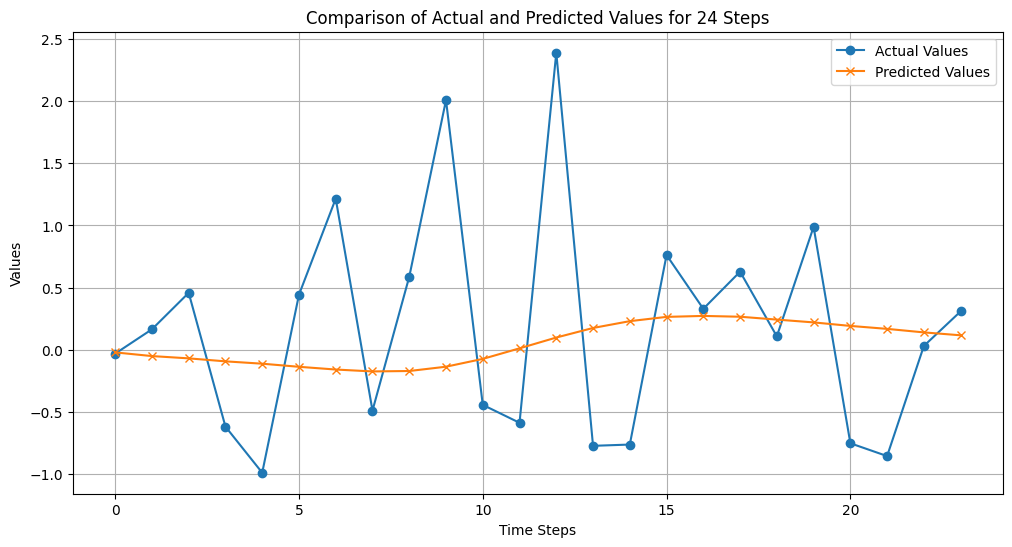

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

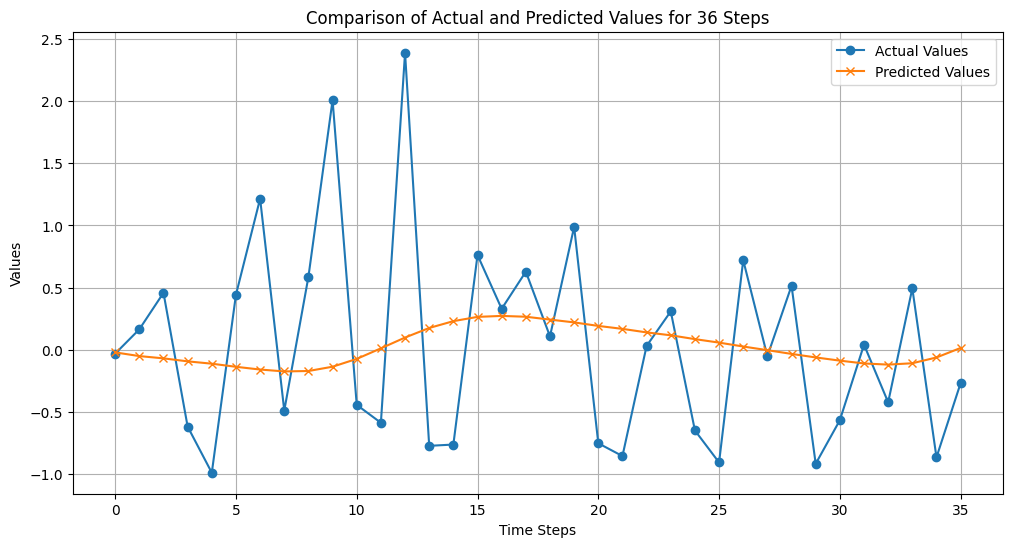

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

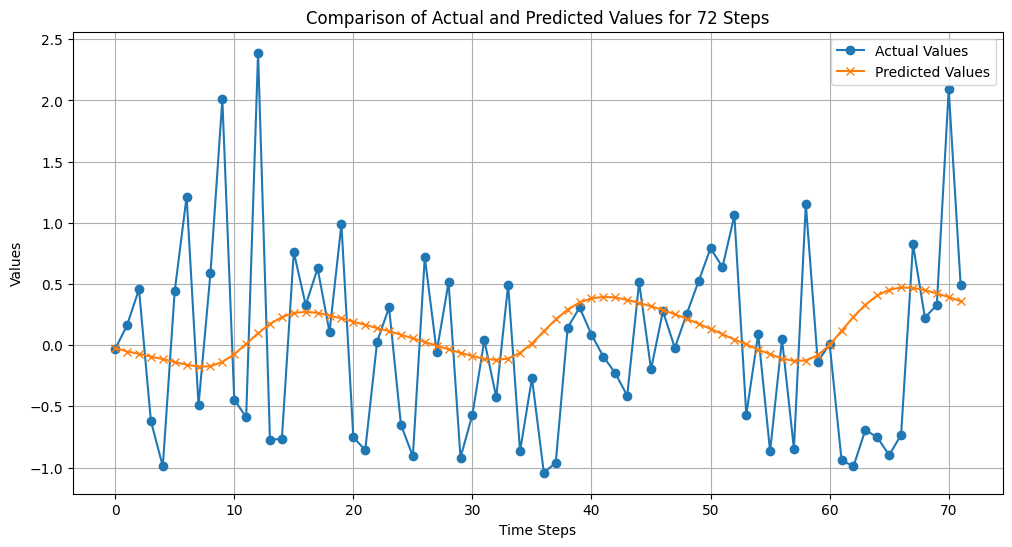

In [39]:
def plot_predictions(time_steps_forecast, model, x_val, y_val):
    for steps in time_steps_forecast:
        predictions = forecast(model, x_val[0], steps)
        true_values = y_val[:steps]
        mse = mean_squared_error(true_values, predictions)
        results.append((steps, mse))
        print(f"Forecast for {steps} hours: MSE = {mse}")

        plt.figure(figsize=(12, 6))
        plt.plot(range(steps), true_values, label='Actual Values', marker='o')
        plt.plot(range(steps), predictions, label='Predicted Values', marker='x')
        plt.title(f'Comparison of Actual and Predicted Values for {steps} Steps')
        plt.xlabel('Time Steps')
        plt.ylabel('Values')
        plt.legend()
        plt.grid(True)
        plt.show()
plot_predictions(time_steps_forecast, model_CNN_AM, x_val, y_val)